<a href="https://colab.research.google.com/github/anastasiaL-cell/Mastery-Projekt/blob/main/Mastery_Projekt_UsersTable_I_Leiker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Die Daten wurden zunächst in Beekeeper Studio gemäß den Anforderungen von Elena vorverarbeitet. Dabei wurden ausschließlich Sessions nach dem 4. Januar 2023 sowie Nutzer mit mehr als sieben Sessions berücksichtigt.

In [ ]:
import pandas as pd
from datetime import datetime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
users = pd.read_csv('/content/drive/MyDrive/users.csv')

In [ ]:
users["birthdate"] = pd.to_datetime(users["birthdate"])

In [ ]:
users["age"] = (datetime.now() - users["birthdate"]).dt.days//365

In [ ]:
users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,45
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54
...,...,...,...,...,...,...,...,...,...,...,...,...
5993,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25,52
5994,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27,47
5995,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30,48
5996,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06,47


In [ ]:
import seaborn as sns

<Axes: xlabel='age', ylabel='Count'>

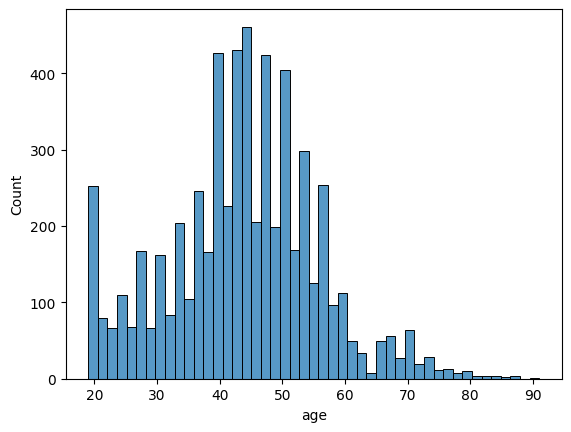

In [ ]:
# Verteilung nach Alter anschauen
sns.histplot(users["age"])

Viele eher jungere Menchen sind dabei. Schauen wir wie viele davon Kinder haben

<Axes: xlabel='age', ylabel='Count'>

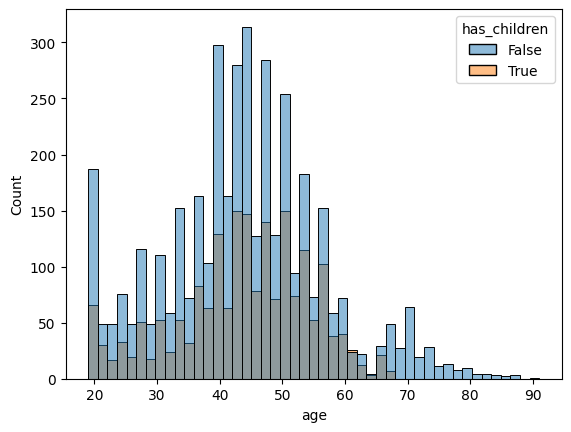

In [ ]:
sns.histplot(users, x ="age", hue = "has_children")

Nach dem Alter von 68 Jahren liegen keine Eintragungen für Kinder mehr vor, da die Kinder dieser älteren Nutzer inzwischen das 18. Lebensjahr überschritten haben und daher nicht mehr als Kinder erfasst werden.

<Axes: xlabel='age', ylabel='Count'>

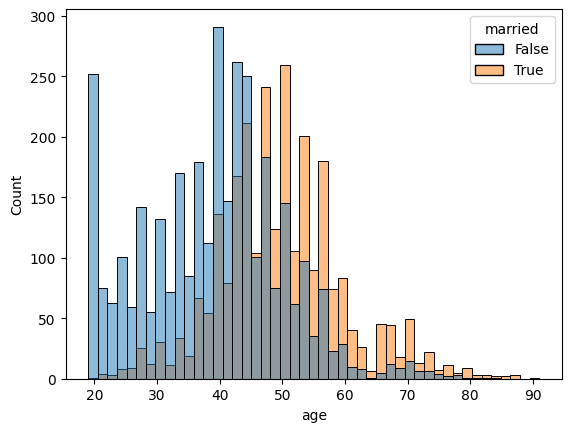

In [ ]:
sns.histplot(users, x ="age", hue = "married")

In [ ]:
users.to_csv('/content/drive/MyDrive/users_cleaned.csv', index = False)

In [ ]:
user_cleaned = pd.read_csv('/content/drive/MyDrive/users_cleaned.csv')

In [ ]:
user_cleaned

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,45
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54
...,...,...,...,...,...,...,...,...,...,...,...,...
5993,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25,52
5994,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27,47
5995,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30,48
5996,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06,47


Sessions Table

In [ ]:
sessions = pd.read_csv("/content/drive/MyDrive/sessions.csv")

In [ ]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49211 entries, 0 to 49210
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              49211 non-null  object 
 1   user_id                 49211 non-null  int64  
 2   trip_id                 16702 non-null  object 
 3   session_start           49211 non-null  object 
 4   session_end             49211 non-null  object 
 5   flight_discount         49211 non-null  bool   
 6   hotel_discount          49211 non-null  bool   
 7   flight_discount_amount  8282 non-null   float64
 8   hotel_discount_amount   6205 non-null   float64
 9   flight_booked           49211 non-null  bool   
 10  hotel_booked            49211 non-null  bool   
 11  page_clicks             49211 non-null  int64  
 12  cancellation            49211 non-null  bool   
dtypes: bool(5), float64(2), int64(2), object(4)
memory usage: 3.2+ MB


In [ ]:
sessions["flight_discount"].sum()

np.int64(8892)

In [ ]:
sessions["flight_discount_amount"].isna()

,flight_discount_amount
0,False
1,True
2,True
3,True
4,True
...,...
49206,True
49207,True
49208,True
49209,True


In [ ]:
sessions["flight_discount_amount"].unique()

array([0.05,  nan, 0.15, 0.1 , 0.3 , 0.4 , 0.2 , 0.25, 0.35, 0.45, 0.6 ,
       0.5 , 0.55])

Missing flight_discount_amount = 0

In [ ]:
sessions["flight_discount_amount"].unique()

array([0.05,  nan, 0.15, 0.1 , 0.3 , 0.4 , 0.2 , 0.25, 0.35, 0.45, 0.6 ,
       0.5 , 0.55])

In [ ]:
sessions.head()

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,430722-1359c68b732c4e79bfbb3f12c72063dd,430722,NaN,2023-01-05 11:04:00,2023-01-05 11:07:56,True,False,0.05,NaN,False,False,32,False
1,431912-97321334a3054f458512aedeedc96514,431912,431912-1f5ebe696cc148c6a7d0234efd857a92,2023-01-05 19:50:00,2023-01-05 19:52:11,False,False,NaN,NaN,True,False,18,False
2,438839-8dadf5ca0f11475fa509f69edc178bab,438839,NaN,2023-01-05 14:19:00,2023-01-05 14:20:31,False,True,NaN,0.05,False,False,12,False
3,450164-3c35bb232f6240b8a30331dcde685071,450164,NaN,2023-01-05 06:09:00,2023-01-05 06:09:46,False,False,NaN,NaN,False,False,6,False
4,452532-f2a7363ac1954df1a502ee169dd514a4,452532,NaN,2023-01-05 14:56:00,2023-01-05 14:57:34,False,False,NaN,NaN,False,False,13,False


In [ ]:
sessions.loc[(sessions["flight_discount"])&(sessions["flight_discount_amount"].isna()),"flight_discount_amount"] = 0

In [ ]:
sessions.groupby("flight_discount")["flight_discount_amount"].apply(lambda x: x.isna().sum())

,flight_discount_amount
flight_discount,
False,40319
True,0


In [ ]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49211 entries, 0 to 49210
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              49211 non-null  object 
 1   user_id                 49211 non-null  int64  
 2   trip_id                 16702 non-null  object 
 3   session_start           49211 non-null  object 
 4   session_end             49211 non-null  object 
 5   flight_discount         49211 non-null  bool   
 6   hotel_discount          49211 non-null  bool   
 7   flight_discount_amount  8892 non-null   float64
 8   hotel_discount_amount   6205 non-null   float64
 9   flight_booked           49211 non-null  bool   
 10  hotel_booked            49211 non-null  bool   
 11  page_clicks             49211 non-null  int64  
 12  cancellation            49211 non-null  bool   
dtypes: bool(5), float64(2), int64(2), object(4)
memory usage: 3.2+ MB


In [ ]:
sessions["flight_discount"].sum()

np.int64(8892)

Missing hotel_discount_amount = 0

In [ ]:
sessions["hotel_discount_amount"].unique()

array([ nan, 0.05, 0.1 , 0.25, 0.2 , 0.15, 0.3 , 0.35, 0.4 , 0.45])

In [ ]:
essions.head()

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,430722-1359c68b732c4e79bfbb3f12c72063dd,430722,NaN,2023-01-05 11:04:00,2023-01-05 11:07:56,True,False,0.05,NaN,False,False,32,False
1,431912-97321334a3054f458512aedeedc96514,431912,431912-1f5ebe696cc148c6a7d0234efd857a92,2023-01-05 19:50:00,2023-01-05 19:52:11,False,False,NaN,NaN,True,False,18,False
2,438839-8dadf5ca0f11475fa509f69edc178bab,438839,NaN,2023-01-05 14:19:00,2023-01-05 14:20:31,False,True,NaN,0.05,False,False,12,False
3,450164-3c35bb232f6240b8a30331dcde685071,450164,NaN,2023-01-05 06:09:00,2023-01-05 06:09:46,False,False,NaN,NaN,False,False,6,False
4,452532-f2a7363ac1954df1a502ee169dd514a4,452532,NaN,2023-01-05 14:56:00,2023-01-05 14:57:34,False,False,NaN,NaN,False,False,13,False


In [ ]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49211 entries, 0 to 49210
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              49211 non-null  object 
 1   user_id                 49211 non-null  int64  
 2   trip_id                 16702 non-null  object 
 3   session_start           49211 non-null  object 
 4   session_end             49211 non-null  object 
 5   flight_discount         49211 non-null  bool   
 6   hotel_discount          49211 non-null  bool   
 7   flight_discount_amount  8892 non-null   float64
 8   hotel_discount_amount   6205 non-null   float64
 9   flight_booked           49211 non-null  bool   
 10  hotel_booked            49211 non-null  bool   
 11  page_clicks             49211 non-null  int64  
 12  cancellation            49211 non-null  bool   
dtypes: bool(5), float64(2), int64(2), object(4)
memory usage: 3.2+ MB


In [ ]:
sessions.loc[(sessions["hotel_discount"])&(sessions["hotel_discount_amount"].isna()),"hotel_discount_amount"] = 0

In [ ]:
sessions.info()
sessions["hotel_discount_amount"].isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49211 entries, 0 to 49210
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              49211 non-null  object 
 1   user_id                 49211 non-null  int64  
 2   trip_id                 16702 non-null  object 
 3   session_start           49211 non-null  object 
 4   session_end             49211 non-null  object 
 5   flight_discount         49211 non-null  bool   
 6   hotel_discount          49211 non-null  bool   
 7   flight_discount_amount  8892 non-null   float64
 8   hotel_discount_amount   6815 non-null   float64
 9   flight_booked           49211 non-null  bool   
 10  hotel_booked            49211 non-null  bool   
 11  page_clicks             49211 non-null  int64  
 12  cancellation            49211 non-null  bool   
dtypes: bool(5), float64(2), int64(2), object(4)
memory usage: 3.2+ MB


np.int64(42396)

In [ ]:
sessions.loc[
    (~sessions["hotel_discount"]) &
    (sessions["hotel_discount_amount"].isna())
].shape

(42396, 13)

In [ ]:
sessions.groupby("hotel_discount")["hotel_discount_amount"].apply(lambda x: x.isna().sum())

,hotel_discount_amount
hotel_discount,
False,42396
True,0


In [ ]:
sessions["hotel_discount"].sum()

np.int64(6815)

In [ ]:
sessions.to_csv('/content/drive/MyDrive/sessions_cleaned.csv', index = False)

## Hotels Table

In [ ]:
hotels = pd.read_csv("/content/drive/MyDrive/hotels.csv")

In [ ]:
hotels.head()

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,118043-3148ad84821c481f81764ed8643adbbf,Fairmont - new york,8,1,2023-07-19 11:00:00,2023-07-27 11:00:00,177
1,204943-07ddf3a4d2a34e03befdbd07c78d9aab,Aman Resorts - new york,2,3,2023-03-06 09:40:43.05,2023-03-08 11:00:00,230
2,229009-406ee07a72a74789bb7b0f5bf0730fe0,Wyndham - edmonton,1,1,2023-05-27 14:18:53.46,2023-05-29 11:00:00,124
3,229330-b73ffe29221b40a086cd0107f85eac2b,Extended Stay - san antonio,1,1,2023-02-26 18:29:05.64,2023-02-28 11:00:00,229
4,283325-dd763c2d6d334b3790266b500393438e,Wyndham - quebec,4,1,2023-03-05 19:18:46.935,2023-03-10 11:00:00,527


Hotel Name

In [ ]:
# Split Hotel Names
hotels[["hotel_name", "city"]] = hotels["hotel_name"].str.split(" - ", expand = True)

In [ ]:
hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,city
0,118043-3148ad84821c481f81764ed8643adbbf,Fairmont,8,1,2023-07-19 11:00:00,2023-07-27 11:00:00,177,new york
1,204943-07ddf3a4d2a34e03befdbd07c78d9aab,Aman Resorts,2,3,2023-03-06 09:40:43.05,2023-03-08 11:00:00,230,new york
2,229009-406ee07a72a74789bb7b0f5bf0730fe0,Wyndham,1,1,2023-05-27 14:18:53.46,2023-05-29 11:00:00,124,edmonton
3,229330-b73ffe29221b40a086cd0107f85eac2b,Extended Stay,1,1,2023-02-26 18:29:05.64,2023-02-28 11:00:00,229,san antonio
4,283325-dd763c2d6d334b3790266b500393438e,Wyndham,4,1,2023-03-05 19:18:46.935,2023-03-10 11:00:00,527,quebec
...,...,...,...,...,...,...,...,...
14308,680735-4849063b26ae4997b20d156efc7dc99a,Conrad,1,2,2023-07-24 14:35:10.185,2023-07-26 11:00:00,202,winnipeg
14309,698573-1ab935d1f3c146ffbbf6fdeeb2415e33,Conrad,10,1,2023-06-08 13:02:30.3,2023-06-19 11:00:00,306,new york
14310,736075-004aa928ddc145cc8f24cfbc6088c8e4,InterContinental,2,1,2023-07-14 13:31:41.655,2023-07-17 11:00:00,147,san jose
14311,757930-4dbfad0ba9324d3d81f03e2e24cebfc8,Starwood,5,1,2023-06-10 11:00:00,2023-06-15 11:00:00,207,edmonton


In [ ]:
hotels["city"].isna().sum()

np.int64(0)

In [ ]:
hotels["city"].nunique()

101

In [ ]:
hotels.info()
hotels.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14313 entries, 0 to 14312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   trip_id             14313 non-null  object
 1   hotel_name          14313 non-null  object
 2   nights              14313 non-null  int64 
 3   rooms               14313 non-null  int64 
 4   check_in_time       14313 non-null  object
 5   check_out_time      14313 non-null  object
 6   hotel_per_room_usd  14313 non-null  int64 
 7   city                14313 non-null  object
dtypes: int64(3), object(5)
memory usage: 894.7+ KB


,0
trip_id,0
hotel_name,0
nights,0
rooms,0
check_in_time,0
check_out_time,0
hotel_per_room_usd,0
city,0


Favorite hotel

In [ ]:
hotels["hotel_name"].value_counts()

,count
hotel_name,
Hilton,768
Best Western,765
Four Seasons,743
NH Hotel,738
Conrad,733
Extended Stay,730
Rosewood,725
Accor,724
Crowne Plaza,722


##Top check in Season

Datumswerte umwandeln

In [ ]:
hotels["check_in_year"] = pd.to_datetime(hotels["check_in_time"], format='mixed').dt.year
hotels["check_in_month"] = pd.to_datetime(hotels["check_in_time"], format='mixed').dt.month
hotels["check_in_day"] = pd.to_datetime(hotels["check_in_time"], format='mixed').dt.day
hotels["check_in_hour"] = pd.to_datetime(hotels["check_in_time"], format='mixed').dt.hour

In [ ]:
hotels["check_out_year"] = pd.to_datetime(hotels["check_out_time"], format='mixed').dt.year
hotels["check_out_month"] = pd.to_datetime(hotels["check_out_time"], format='mixed').dt.month
hotels["check_out_day"] = pd.to_datetime(hotels["check_out_time"], format='mixed').dt.day
hotels["check_out_hour"] = pd.to_datetime(hotels["check_out_time"], format='mixed').dt.hour

In [ ]:
hotels.dtypes

,0
trip_id,object
hotel_name,object
nights,int64
rooms,int64
check_in_time,object
check_out_time,object
hotel_per_room_usd,int64
city,object
check_in_year,int32
check_in_month,int32


Zeitwerte umwandlen

In [ ]:
hotels["check_in_time"] = pd.to_datetime(hotels["check_in_time"],format="mixed")

hotels["check_out_time"] = pd.to_datetime(hotels["check_out_time"],format="mixed")

In [ ]:
hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,city,check_in_year,check_in_month,check_in_day,check_in_hour,check_out_year,check_out_month,check_out_day,check_out_hour
0,118043-3148ad84821c481f81764ed8643adbbf,Fairmont,8,1,2023-07-19 11:00:00.000,2023-07-27 11:00:00,177,new york,2023,7,19,11,2023,7,27,11
1,204943-07ddf3a4d2a34e03befdbd07c78d9aab,Aman Resorts,2,3,2023-03-06 09:40:43.050,2023-03-08 11:00:00,230,new york,2023,3,6,9,2023,3,8,11
2,229009-406ee07a72a74789bb7b0f5bf0730fe0,Wyndham,1,1,2023-05-27 14:18:53.460,2023-05-29 11:00:00,124,edmonton,2023,5,27,14,2023,5,29,11
3,229330-b73ffe29221b40a086cd0107f85eac2b,Extended Stay,1,1,2023-02-26 18:29:05.640,2023-02-28 11:00:00,229,san antonio,2023,2,26,18,2023,2,28,11
4,283325-dd763c2d6d334b3790266b500393438e,Wyndham,4,1,2023-03-05 19:18:46.935,2023-03-10 11:00:00,527,quebec,2023,3,5,19,2023,3,10,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14308,680735-4849063b26ae4997b20d156efc7dc99a,Conrad,1,2,2023-07-24 14:35:10.185,2023-07-26 11:00:00,202,winnipeg,2023,7,24,14,2023,7,26,11
14309,698573-1ab935d1f3c146ffbbf6fdeeb2415e33,Conrad,10,1,2023-06-08 13:02:30.300,2023-06-19 11:00:00,306,new york,2023,6,8,13,2023,6,19,11
14310,736075-004aa928ddc145cc8f24cfbc6088c8e4,InterContinental,2,1,2023-07-14 13:31:41.655,2023-07-17 11:00:00,147,san jose,2023,7,14,13,2023,7,17,11
14311,757930-4dbfad0ba9324d3d81f03e2e24cebfc8,Starwood,5,1,2023-06-10 11:00:00.000,2023-06-15 11:00:00,207,edmonton,2023,6,10,11,2023,6,15,11


Übernachtungen berechnen

In [ ]:
hotels["stay_length"] = (hotels["check_out_time"] - hotels["check_in_time"]).dt.days

In [ ]:
hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,city,check_in_year,check_in_month,check_in_day,check_in_hour,check_out_year,check_out_month,check_out_day,check_out_hour,stay_length
0,118043-3148ad84821c481f81764ed8643adbbf,Fairmont,8,1,2023-07-19 11:00:00.000,2023-07-27 11:00:00,177,new york,2023,7,19,11,2023,7,27,11,8
1,204943-07ddf3a4d2a34e03befdbd07c78d9aab,Aman Resorts,2,3,2023-03-06 09:40:43.050,2023-03-08 11:00:00,230,new york,2023,3,6,9,2023,3,8,11,2
2,229009-406ee07a72a74789bb7b0f5bf0730fe0,Wyndham,1,1,2023-05-27 14:18:53.460,2023-05-29 11:00:00,124,edmonton,2023,5,27,14,2023,5,29,11,1
3,229330-b73ffe29221b40a086cd0107f85eac2b,Extended Stay,1,1,2023-02-26 18:29:05.640,2023-02-28 11:00:00,229,san antonio,2023,2,26,18,2023,2,28,11,1
4,283325-dd763c2d6d334b3790266b500393438e,Wyndham,4,1,2023-03-05 19:18:46.935,2023-03-10 11:00:00,527,quebec,2023,3,5,19,2023,3,10,11,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14308,680735-4849063b26ae4997b20d156efc7dc99a,Conrad,1,2,2023-07-24 14:35:10.185,2023-07-26 11:00:00,202,winnipeg,2023,7,24,14,2023,7,26,11,1
14309,698573-1ab935d1f3c146ffbbf6fdeeb2415e33,Conrad,10,1,2023-06-08 13:02:30.300,2023-06-19 11:00:00,306,new york,2023,6,8,13,2023,6,19,11,10
14310,736075-004aa928ddc145cc8f24cfbc6088c8e4,InterContinental,2,1,2023-07-14 13:31:41.655,2023-07-17 11:00:00,147,san jose,2023,7,14,13,2023,7,17,11,2
14311,757930-4dbfad0ba9324d3d81f03e2e24cebfc8,Starwood,5,1,2023-06-10 11:00:00.000,2023-06-15 11:00:00,207,edmonton,2023,6,10,11,2023,6,15,11,5


In [ ]:
hotels[["nights", "stay_length"]].head()

,nights,stay_length
0,8,8
1,2,2
2,1,1
3,1,1
4,4,4


In [ ]:
(hotels["nights"] == hotels["stay_length"]).value_counts()

,count
True,12984
False,1329


In [ ]:
hotels.loc[hotels["nights"] != hotels["stay_length"],["check_in_time","check_out_time","nights","stay_length"]].head(10)

,check_in_time,check_out_time,nights,stay_length
6,2023-07-04 11:34:30.405,2023-07-06 11:00:00,2,1
8,2023-04-06 11:46:28.650,2023-04-08 11:00:00,2,1
24,2023-01-15 11:22:34.275,2023-01-16 11:00:00,1,0
29,2023-01-15 11:44:13.425,2023-01-15 11:00:00,0,-1
39,2023-02-12 11:43:49.845,2023-02-19 11:00:00,7,6
72,2023-07-13 11:22:57.855,2023-07-15 11:00:00,2,1
74,2023-01-12 11:54:26.145,2023-01-15 11:00:00,3,2
78,2023-02-01 11:34:48.675,2023-02-02 11:00:00,1,0
101,2023-01-22 11:24:19.530,2023-01-28 11:00:00,6,5
112,2023-01-29 11:29:46.230,2023-02-06 11:00:00,8,7


In [ ]:
hotels["hotel_total_cost"] = (hotels["nights"] * hotels["rooms"] * hotels["hotel_per_room_usd"])

Negative nights

In [ ]:
hotels["nights"] = hotels["nights"].abs()

In [ ]:
hotels["stay_length"] = hotels["stay_length"].abs()

In [ ]:
hotels.to_csv('/content/drive/MyDrive/hotels_cleaned.csv', index = False)

In [ ]:
hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,city,check_in_year,check_in_month,check_in_day,check_in_hour,check_out_year,check_out_month,check_out_day,check_out_hour,stay_length,hotel_total_cost
0,118043-3148ad84821c481f81764ed8643adbbf,Fairmont,8,1,2023-07-19 11:00:00.000,2023-07-27 11:00:00,177,new york,2023,7,19,11,2023,7,27,11,8,1416
1,204943-07ddf3a4d2a34e03befdbd07c78d9aab,Aman Resorts,2,3,2023-03-06 09:40:43.050,2023-03-08 11:00:00,230,new york,2023,3,6,9,2023,3,8,11,2,1380
2,229009-406ee07a72a74789bb7b0f5bf0730fe0,Wyndham,1,1,2023-05-27 14:18:53.460,2023-05-29 11:00:00,124,edmonton,2023,5,27,14,2023,5,29,11,1,124
3,229330-b73ffe29221b40a086cd0107f85eac2b,Extended Stay,1,1,2023-02-26 18:29:05.640,2023-02-28 11:00:00,229,san antonio,2023,2,26,18,2023,2,28,11,1,229
4,283325-dd763c2d6d334b3790266b500393438e,Wyndham,4,1,2023-03-05 19:18:46.935,2023-03-10 11:00:00,527,quebec,2023,3,5,19,2023,3,10,11,4,2108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14308,680735-4849063b26ae4997b20d156efc7dc99a,Conrad,1,2,2023-07-24 14:35:10.185,2023-07-26 11:00:00,202,winnipeg,2023,7,24,14,2023,7,26,11,1,404
14309,698573-1ab935d1f3c146ffbbf6fdeeb2415e33,Conrad,10,1,2023-06-08 13:02:30.300,2023-06-19 11:00:00,306,new york,2023,6,8,13,2023,6,19,11,10,3060
14310,736075-004aa928ddc145cc8f24cfbc6088c8e4,InterContinental,2,1,2023-07-14 13:31:41.655,2023-07-17 11:00:00,147,san jose,2023,7,14,13,2023,7,17,11,2,294
14311,757930-4dbfad0ba9324d3d81f03e2e24cebfc8,Starwood,5,1,2023-06-10 11:00:00.000,2023-06-15 11:00:00,207,edmonton,2023,6,10,11,2023,6,15,11,5,1035


In [ ]:
# vor dem Modelltraining
# hotels.drop(columns=["check_in_time", "check_out_time"], inplace=True)